In [1]:
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain.chat_models import init_chat_model

model = init_chat_model(
        "qwen-local",
        model_provider = "openai",
        base_url = "http://localhost:8080/v1", 
        api_key = ""
    )

# Prompts-1
prompts = [SystemMessage("You are a helpful assistant."), HumanMessage("Hello, how are you?")]
response = model.invoke(prompts)  
print(response.content)

# Prompts-2
prompts = [SystemMessage("You are a helpful assistant."), HumanMessage("Implement segment tree with lazy evaluation?")]
response = model.invoke(prompts)  
print(response.content)

Hello! I'm functioning well, thank you for asking. I'm always excited to chat and help out! 😊 How can I assist you today?
Sure! Below is a **complete implementation of a Segment Tree with Lazy Propagation** in Python. This implementation supports:

- Range updates (e.g., adding a value to all elements in a range)
- Point queries (e.g., getting the sum at a specific index)
- Range queries (e.g., getting the sum over a range)

We'll use **lazy propagation** to efficiently handle range updates and avoid updating every single element during each operation.

---

### ✅ Segment Tree with Lazy Evaluation (Supports Range Updates & Range Queries)

```python
class SegmentTree:
    def __init__(self, arr):
        self.n = len(arr)
        self.tree = [0] * (4 * self.n)
        self.lazy = [0] * (4 * self.n)  # lazy[i] stores pending updates for node i
        self.build(arr, 0, 0, self.n - 1)

    def build(self, arr, node, start, end):
        if start == end:
            self.tree[node] = arr[

In [18]:
from typing import Any
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain.messages import AIMessage, AIMessageChunk, AnyMessage, ToolMessage


def get_weather(city: str) -> str:
    """Get weather for a given city."""
    return f"It's always sunny in {city}!"


model = ChatOpenAI(base_url = "http://localhost:8080/v1", api_key = "")
agent = create_agent(model=model,
                     tools=[get_weather])


def _render_message_chunk(token: AIMessageChunk) -> None:
    if token.text:
        print(token.text, end="|")
    if token.tool_call_chunks:
        '''
        This section prints the argument of the function which the LLM figures out
        [{'name': 'get_weather', 'args': '', 'id': '5qtwjgZgjZglq3e1PiA1mPQxzlluaEqe', 'index': 0, 'type': 'tool_call_chunk'}]
        [{'name': None, 'args': '{"', 'id': None, 'index': 0, 'type': 'tool_call_chunk'}]
        [{'name': None, 'args': 'city', 'id': None, 'index': 0, 'type': 'tool_call_chunk'}]
        [{'name': None, 'args': '":', 'id': None, 'index': 0, 'type': 'tool_call_chunk'}]
        [{'name': None, 'args': '"', 'id': None, 'index': 0, 'type': 'tool_call_chunk'}]
        [{'name': None, 'args': 'Boston', 'id': None, 'index': 0, 'type': 'tool_call_chunk'}]
        [{'name': None, 'args': '"}', 'id': None, 'index': 0, 'type': 'tool_call_chunk'}]
        '''
        print(token.tool_call_chunks)


def _render_completed_message(message: AnyMessage) -> None:
    if isinstance(message, AIMessage) and message.tool_calls:
        print(f"Tool calls: {message.tool_calls}")
    if isinstance(message, ToolMessage):
        print(f"Tool response: {message.content_blocks}")
    print(f'---'*20)


'''
agent.stream(...) — instead of waiting for the full response, this streams results incrementally as the agent works through its steps.
{"messages": [input_message]} — the input to the agent, passed as a dict with a messages key (standard LangGraph state format).

"messages" — yields individual message chunks as they're generated (token by token or chunk by chunk), useful for streaming LLM output to a UI in real time
"updates" — yields the state changes after each node in the graph finishes executing, useful for knowing which step just completed (e.g. tool call, LLM response)
version="v2" — specifies the streaming protocol version. v2 changes the shape of the yielded chunks — each item in the loop becomes a tuple like (event_type, data) rather than a plain dict, so you'd typically unpack it like:
'''
input_message = {"role": "user", "content": "What is the weather in Boston?"}
config = {"recursion_limit": 10, "configurable": {"thread_id": "1"}} # To prevent infinite recursion.
for chunk in agent.stream(
    {"messages": [input_message]},
    stream_mode=["messages", "updates"],
    version="v2",
    config=config
):
    if chunk["type"] == "messages":
        token, metadata = chunk["data"]
        if isinstance(token, AIMessageChunk):
            _render_message_chunk(token)
    elif chunk["type"] == "updates":
        print(f'{chunk["type"]=} {chunk=}')
        print(f'---'*20)
        for source, update in chunk["data"].items():
            if source in ("model", "tools"):  # `source` captures node name
                _render_completed_message(update["messages"][-1])

'''
Explanations:
The AIMessage will have a tool_calls section which was created by the LLM, as shown below.
>>>
Tool calls: [{'name': 'get_weather', 'args': {'city': 'Boston'}, 'id': 'ehoy6QoOqJIWkmlIUIEJ2G6iGIMDyHZQ', 'type': 'tool_call'}]

Then the tool is called.
>>>
Tool response: [{'type': 'text', 'text': "It's always sunny in Boston!"}]

Finally it's sent to the LLM for the final response
'''

'''
1. How it Knows "What to Do"
The agent doesn't "know" in the sense of a pre-written script. It relies on System Prompting and Function Calling (Tool Definition):
Preparation: You provide the LLM with a list of tool definitions (JSON schemas).
Decision: The LLM looks at the user query. If the query requires data it doesn't have (e.g., "What is the weather?"), it identifies that a tool matches this need.
Execution: Instead of talking to the user, the LLM outputs a specific "Tool Call" object (like the ones you've been formatting).
Feedback: The output of that tool is appended to the messages. The LLM sees: "User asked X, I called Tool Y, and got Result Z." It then realizes it now has enough info to summarize.

2. Can it go in a cycle?
Yes, absolutely. This is a common failure mode called a "Looping Hallucination."
A cycle happens if:
The tool fails: The tool returns an error or "No data found," and the LLM thinks, "Maybe if I try again with slightly different args, it will work."
The prompt is vague: The LLM isn't sure it has the right answer yet and keeps calling the same tool to "verify."
Bad Logic: The LLM gets stuck in a logic loop where it thinks it still needs information that the tool isn't providing.

3. Preventing Infinite Cycles
To stop an agent from spinning its wheels forever and burning your API credits, LangGraph uses two main safety rails:
recursion_limit: When you call app.invoke(..., config={"recursion_limit": 10}), the graph will forcibly stop if it hits 10 transitions. This is your "circuit breaker."
Stop Sequences: You can prompt the model to stop if it sees it is repeating itself.
'''
x = 1


[{'name': 'get_weather', 'args': '', 'id': 'dnlAIDAdgTrgnhfmx5MG1ZDurobnCjIl', 'index': 0, 'type': 'tool_call_chunk'}]
[{'name': None, 'args': '{"', 'id': None, 'index': 0, 'type': 'tool_call_chunk'}]
[{'name': None, 'args': 'city', 'id': None, 'index': 0, 'type': 'tool_call_chunk'}]
[{'name': None, 'args': '":', 'id': None, 'index': 0, 'type': 'tool_call_chunk'}]
[{'name': None, 'args': '"', 'id': None, 'index': 0, 'type': 'tool_call_chunk'}]
[{'name': None, 'args': 'Boston', 'id': None, 'index': 0, 'type': 'tool_call_chunk'}]
[{'name': None, 'args': '"}', 'id': None, 'index': 0, 'type': 'tool_call_chunk'}]
chunk["type"]='updates' chunk={'type': 'updates', 'ns': (), 'data': {'model': {'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-3.5-turbo', 'system_fingerprint': 'b7195-47a268ea5', 'model_provider': 'openai'}, id='lc_run--019e1348-6a50-7ee1-a580-b84d21d25d99', tool_calls=[{'name': 'get_weather', 'args': {'

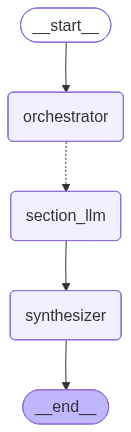

Certainly! Below is a clear, professional Python script that demonstrates how to define **Project Scope and Objectives** in a structured format — using Python dictionaries, lists, and formatting for readability.

This script can be used as a template or foundation for any software project planning phase where scope and objectives need to be formally documented.

```python
# Project Scope and Objectives Definition Script

def define_project_scope_and_objectives(project_name):
    """
    Defines the scope and objectives of a given project in structured format.
    
    Parameters:
        project_name (str): Name of the project
    
    Returns:
        dict: A dictionary containing project scope, objectives, deliverables, constraints, and assumptions
    """
    
    # Project Scope
    scope = {
        "description": f"This project aims to {project_name} by delivering key features that address user needs and business goals.",
        "inclusions": [
            "Develop a user-friend

In [3]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from typing import List, Annotated
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from IPython.display import Image, display
from langgraph.types import Send
import operator
import re 

llm = ChatOpenAI(
    base_url='http://localhost:8080/v1',
    api_key='na'
)

class Section(BaseModel):
    description: str = Field(
        description='Brief overview of the code you want to generate.'
    )

# Graph state 
class State5(TypedDict):
    main_topic: str 
    sections: List[Section] 
    '''
    # Custom merge logic
    field: Annotated[dict, lambda a, b: {**a, **b}]
    '''
    completed_sections: Annotated[list, operator.add] 
    final_code: str 
    
# Worker state
class WorkerState(TypedDict):
    section: Section

# Node(s)
def orchestrator(state: State5):
    """Orchestrator that generates a plan for the code"""
    # Generate queries
    report_sections = llm.invoke(
        [
            SystemMessage(content="""Generate a plan to build a big python project. 
Put each sub plan for the task must be enclosed within <plan></plan>, as shown below
<plan>Sub Plan 1</plan>
<plan>Sub Plan 2</plan> 
...
"""),
            HumanMessage(content=f"Here is the project topic: {state['main_topic']}"),
        ]
    )
    # Parse the plan.
    sections = []
    for match in re.findall(r"<plan>(.*?)</plan>", report_sections.content):
        sections.append(Section(**{'description': match}))
    return {"sections": sections}

def section_llm(state: WorkerState):
    section = llm.invoke(
        [
            SystemMessage(content = "Write a python code following the provided description."),
            HumanMessage(content = f"Here is the description: {state['section'].description}")
        ]
    )
    return {'completed_sections': [section.content]}

def synthesizer(state: State5):
    """Synthesize full report from sections"""
    # List of completed sections
    completed_sections = state["completed_sections"]
    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)
    return {"final_code": completed_report_sections}

# Conditional edge function to create llm_call workers that each write a section of the report
def assign_workers(state: State5):
    """Assign a worker to each section in the plan"""
    # Kick off section writing in parallel via Send() API
    return [Send("section_llm", {"section": s}) for s in state["sections"]]


workflow = StateGraph(State5)
workflow.add_node('orchestrator', orchestrator)
workflow.add_node('section_llm', section_llm)
workflow.add_node('synthesizer', synthesizer)

workflow.add_edge(START, 'orchestrator')
'''
The list ["section_llm"] here isn't a routing map — it's just telling LangGraph 
"this edge can send to section_llm" so the graph knows about the connection for validation and visualization. 
The actual routing logic (how many times, with what state) is entirely determined by the Send objects at runtime.
'''
workflow.add_conditional_edges(
    "orchestrator", assign_workers, ["section_llm"]
)
workflow.add_edge('section_llm', 'synthesizer')
workflow.add_edge('synthesizer', END)

orchestrator = workflow.compile()
# Show the workflow
display(Image(orchestrator.get_graph().draw_mermaid_png()))
msg = orchestrator.invoke({'main_topic': 'Design a ticketing system.'})
print(msg['final_code'])